# YZM0206 Proje - Baseline CNN Modeli

Bu notebookta EuroSAT RGB veri seti üzerinde transfer learning kullanılmadan basit bir CNN modeli eğitilecektir. Bu model, sonraki notebooklarda denenecek MobileNetV2, DenseNet121 ve InceptionV3 gibi hazır ağırlıklı modeller için karşılaştırma noktası olarak kullanılacaktır.

Bu aşamada yapılan işlemler:

1. Veri hazırlama notebookunda oluşturulan train / validation / test splitinin okunması
2. Eğitim sırasında görüntülerin 224x224 boyutuna getirilmesi ve normalizasyon uygulanması
3. Basit CNN mimarisinin kurulması
4. Modelin eğitim ve validation performansının izlenmesi
5. Test kümesi üzerinde final değerlendirme yapılması
6. Confusion matrix ve classification report ile sınıf bazlı performansın incelenmesi

## Kütüphaneler ve proje dizinleri

Bu bölümde model eğitimi, performans ölçümü ve görselleştirme için gerekli kütüphaneler içe aktarılmıştır. Sonuçların tekrar üretilebilir olması için seed değerleri sabitlenmiştir.

In [2]:
import json
import random
import shutil
import time
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")

try:
    import importlib
    importlib.import_module("google.colab.drive").mount("/content/drive")
except Exception:
    pass


def find_project_dir():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for root in [Path("/content") / "drive" / "MyDrive", Path("/content") / "drive" / "Shareddrives"]:
        project_candidate = root / "YZM0206 Proje"
        if project_candidate.exists():
            candidates.append(project_candidate)

    for candidate in candidates:
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError("Proje klasörü bulunamadı. Notebook proje klasörü içinden çalıştırılmalıdır.")


def count_images(directory):
    if not directory.exists():
        return 0
    return sum(1 for _ in directory.glob("*/*.jpg"))


def split_zip_counts(zip_path):
    counts = {"train": 0, "valid": 0, "test": 0}

    if not zip_path.exists():
        return counts

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        for name in zip_ref.namelist():
            parts = name.split("/")
            if len(parts) == 3 and parts[0] in counts and name.lower().endswith(".jpg"):
                counts[parts[0]] += 1

    return counts


def prepare_local_split_from_zip():
    if not SPLIT_ZIP_PATH.exists():
        raise FileNotFoundError("Split zip dosyası bulunamadı. Önce 01_dataset_preparation.ipynb çalıştırılmalıdır.")

    expected = split_zip_counts(SPLIT_ZIP_PATH)

    if sum(expected.values()) != 27000:
        raise RuntimeError("Split zip dosyası beklenen 27000 görüntüyü içermiyor.")

    split_ready = all(count_images(SPLIT_DIRS[name]) == count for name, count in expected.items())

    if split_ready:
        return

    if SPLIT_ROOT.exists():
        shutil.rmtree(SPLIT_ROOT)

    SPLIT_ROOT.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(SPLIT_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(SPLIT_ROOT)

    if not all(count_images(SPLIT_DIRS[name]) == count for name, count in expected.items()):
        raise RuntimeError("Split zip dosyası çalışma alanına eksik çıkarıldı.")


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SPLIT_ZIP_PATH = PROCESSED_DIR / "eurosat_split_seed42.zip"

LOCAL_WORK_DIR = Path("/content/eurosat_work") if Path("/content").exists() else DATA_DIR / "local_work"
SPLIT_ROOT = LOCAL_WORK_DIR / "split_seed42"
SPLIT_DIRS = {
    "train": SPLIT_ROOT / "train",
    "valid": SPLIT_ROOT / "valid",
    "test": SPLIT_ROOT / "test",
}
TRAIN_DIR = SPLIT_DIRS["train"]
VALID_DIR = SPLIT_DIRS["valid"]
TEST_DIR = SPLIT_DIRS["test"]

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in [FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

prepare_local_split_from_zip()

print("Hazırlık tamamlandı.")
print("TensorFlow:", tf.__version__)
print("Train görüntü sayısı:", count_images(TRAIN_DIR))
print("Validation görüntü sayısı:", count_images(VALID_DIR))
print("Test görüntü sayısı:", count_images(TEST_DIR))

Mounted at /content/drive
Hazırlık tamamlandı.
TensorFlow: 2.20.0
Train görüntü sayısı: 18900
Validation görüntü sayısı: 4050
Test görüntü sayısı: 4050


## Veri kümelerini yükleme

Bu bölümde veri hazırlama notebookunda oluşturulan `eurosat_split_seed42.zip` dosyası açılmış ve model eğitimi için aynı `train`, `valid` ve `test` kümeleri kullanılmıştır. Bu nedenle baseline CNN ile transfer learning modelleri aynı split üzerinde karşılaştırılacaktır.

Görüntüler model girişine uygun olarak `224x224` boyutuna getirilmiştir. Bu işlem ham dosyaları değiştirmez; yalnızca eğitim sırasında modele verilen tensörlerin boyutunu standartlaştırır.

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42
)

valid_data = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_data.class_names
num_classes = len(class_names)

print("Sınıf sayısı:", num_classes)
print(class_names)

Found 18900 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Sınıf sayısı: 10
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Normalizasyon

Baseline CNN modelinde piksel değerleri 0-255 aralığından 0-1 aralığına çevrilmiştir. Bu işlem modelin daha stabil öğrenmesine yardımcı olur.

In [4]:
def normalize_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_data = train_data.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
valid_data = valid_data.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_data = test_data.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Veri pipeline hazır.")

Veri pipeline hazır.


## Baseline CNN mimarisi

Bu model herhangi bir hazır ağırlık kullanmadan sıfırdan eğitilecektir. Bu nedenle çok karmaşık bir mimari yerine, birkaç convolution ve pooling katmanından oluşan sade bir CNN tercih edilmiştir.

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Dense(num_classes, activation="softmax")
], name="baseline_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

## Model eğitimi

Model, validation accuracy değeri izlenerek eğitilmiştir. `EarlyStopping` overfitting riskini azaltmak için kullanılmıştır. En iyi validation sonucunu veren model ağırlıkları `models/baseline_cnn_best.keras` dosyasına kaydedilecektir.

In [6]:
EPOCHS = 20

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / "baseline_cnn_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=EPOCHS,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Eğitim süresi (sn):", round(training_time, 2))

Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2603 - loss: 1.8959
Epoch 1: val_accuracy improved from None to 0.45111, saving model to /content/drive/MyDrive/YZM0206 Proje/models/baseline_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/baseline_cnn_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 48s 65ms/step - accuracy: 0.3278 - loss: 1.7223 - val_accuracy: 0.4511 - val_loss: 1.4924
Epoch 2/20
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4795 - loss: 1.4142
Epoch 2: val_accuracy improved from 0.45111 to 0.60370, saving model to /content/drive/MyDrive/YZM0206 Proje/models/baseline_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/baseline_cnn_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.5189 - loss: 1.3281 - val_accuracy: 0.6037 - val_loss: 1.0881
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5881 - loss: 1.1360
Epoch 3: val_accur

## Eğitim grafikleri

Accuracy ve loss grafikleri, modelin eğitim sırasında öğrenip öğrenmediğini ve validation setinde overfitting belirtisi olup olmadığını görmek için çizilmiştir.

In [7]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.327778,1.722275,0.451111,1.492392
1,0.518889,1.328143,0.603704,1.088062
2,0.598995,1.118902,0.641235,0.992069
3,0.626984,1.045349,0.655802,0.938095
4,0.645767,1.000990,0.677284,0.883223
5,0.659471,0.958745,0.682222,0.868846
6,0.676455,0.895931,0.702222,0.792189
7,0.697884,0.835760,0.717778,0.745603
8,0.711429,0.803870,0.740741,0.688433
9,0.722593,0.762602,0.748148,0.675517


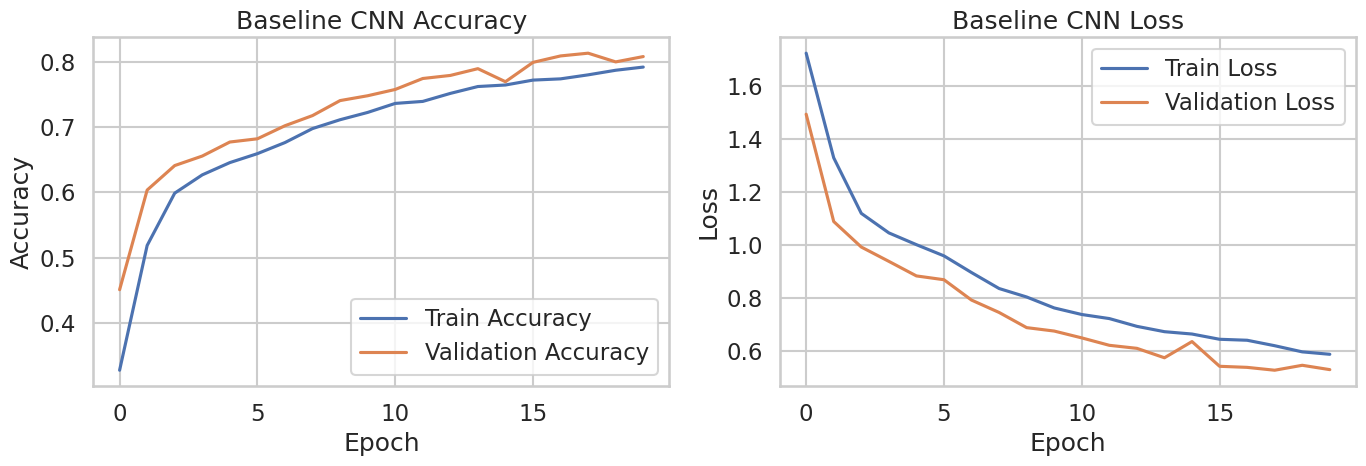

In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_cnn_accuracy_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Eğitim eğrilerinin yorumu

Baseline CNN modeli 20 epoch boyunca eğitilmiştir. İlk epochta train accuracy 0.3278, validation accuracy ise 0.4511 olarak başlamıştır. Son epochta train accuracy 0.7921, validation accuracy 0.8081 değerine ulaşmıştır.

En iyi validation accuracy değeri 0.8133 olarak elde edilmiştir. Eğitim boyunca loss değeri 1.7223 seviyesinden 0.5880 seviyesine düşmüştür. Bu durum modelin verideki temel görsel örüntüleri öğrendiğini göstermektedir.

Train ve validation accuracy değerleri birbirine yakın ilerlediği için bu modelde çok belirgin bir overfitting gözlenmemiştir. Ancak validation accuracy yaklaşık 0.81 seviyesinde kaldığı için sıfırdan eğitilen sade CNN mimarisinin EuroSAT veri setinde sınırlı temsil gücüne sahip olduğu söylenebilir.

## Test kümesi değerlendirmesi

Test kümesi eğitim sırasında kullanılmamıştır. Bu nedenle modelin daha tarafsız performansını görmek için final değerlendirme bu küme üzerinde yapılmıştır.

In [9]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test loss değeri:", test_loss)
print("Test accuracy değeri:", test_accuracy)

127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8207 - loss: 0.5135
Test loss değeri: 0.5135378837585449
Test accuracy değeri: 0.8207407593727112


## Test sonucu yorumu

Test kümesi üzerinde baseline CNN modeli 0.8207 accuracy ve 0.5135 loss değerine ulaşmıştır. Bu sonuç, modelin hiç görmediği 4.050 test görüntüsünün yaklaşık %82'sini doğru sınıflandırdığını göstermektedir.

Bu değer proje için temel referans noktasıdır. Transfer learning modellerinin başarısı, bu baseline değerin üzerine ne kadar çıkabildikleriyle değerlendirilecektir.

## Tahminlerin alınması

Confusion matrix ve classification report hesaplamak için test kümesindeki gerçek sınıflar ve model tahminleri ayrı listelerde toplanmıştır.

In [10]:
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Tahmin sayısı:", len(y_pred))

Tahmin sayısı: 4050


## Classification report

Accuracy tek başına modelin sınıf bazlı davranışını açıklamak için yeterli değildir. Bu nedenle precision, recall ve F1-score değerleri de incelenmiştir.

In [11]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(REPORTS_DIR / "baseline_cnn_classification_report.csv", encoding="utf-8-sig")
report_df

,precision,recall,f1-score,support
AnnualCrop,0.888361,0.831111,0.858783,450.000000
Forest,0.920561,0.875556,0.897494,450.000000
HerbaceousVegetation,0.846734,0.748889,0.794811,450.000000
Highway,0.647059,0.557333,0.598854,375.000000
Industrial,0.885496,0.928000,0.906250,375.000000
Pasture,0.810458,0.826667,0.818482,300.000000
PermanentCrop,0.739612,0.712000,0.725543,375.000000
Residential,0.816479,0.968889,0.886179,450.000000
River,0.686636,0.794667,0.736712,375.000000
SeaLake,0.913717,0.917778,0.915743,450.000000


## Sınıf bazlı performans yorumu

Classification report incelendiğinde baseline CNN modelinin bazı sınıflarda belirgin şekilde daha başarılı olduğu görülmektedir. En yüksek F1-score değerleri SeaLake (0.9157), Industrial (0.9063), Forest (0.8975) ve Residential (0.8862) sınıflarında elde edilmiştir. Bu sınıflar uydu görüntülerinde daha ayırt edilebilir renk ve doku yapıları içerdiği için model tarafından daha kolay öğrenilmiştir.

En düşük F1-score değerleri ise Highway (0.5989), PermanentCrop (0.7255) ve River (0.7367) sınıflarında görülmektedir. Highway sınıfında recall değerinin 0.5573 olması, bu sınıfa ait birçok görüntünün başka sınıflarla karıştırıldığını göstermektedir. River ve PermanentCrop sınıflarında da görsel yapının bazı örneklerde tarım, yol veya bitki örtüsü sınıflarına yaklaşması performansı düşürmüş olabilir.

Bu sonuçlar baseline CNN'in genel yapıyı öğrendiğini, ancak özellikle ince çizgisel yapılar ve tarımsal dokular gibi daha karmaşık sınıflarda zorlandığını göstermektedir.

## Confusion matrix

Confusion matrix, modelin hangi sınıfları birbiriyle karıştırdığını görmek için kullanılmıştır. Bu analiz özellikle görsel olarak benzer arazi sınıflarında önemlidir.

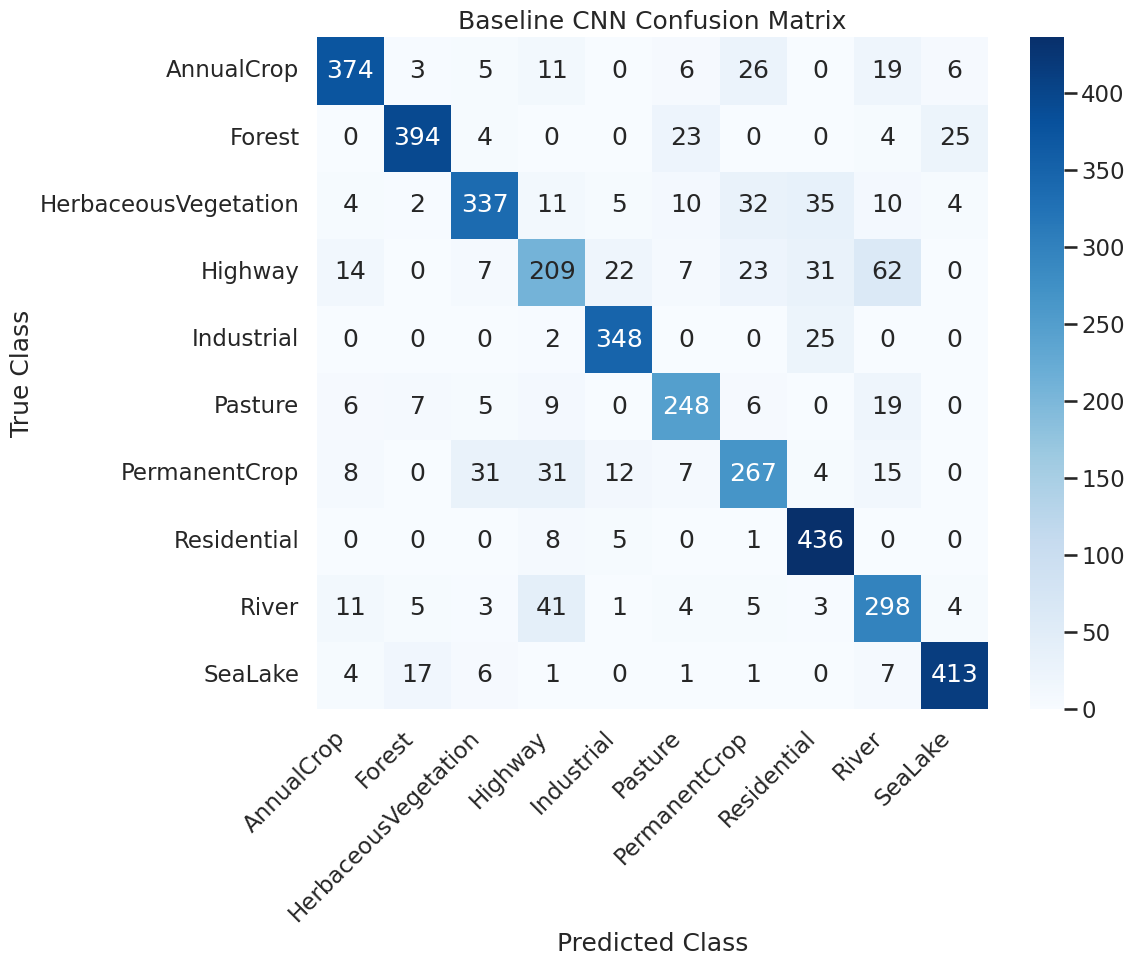

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_cnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Confusion matrix yorumu

Confusion matrix çıktısı, classification reportta görülen sınıf bazlı farkları desteklemektedir. SeaLake, Industrial, Forest ve Residential sınıflarında doğru tahmin sayıları daha yüksektir. Buna karşılık Highway, River ve PermanentCrop sınıflarında hatalar daha belirgin hale gelmektedir.

Bu sonuç baseline modelin güçlü ve zayıf taraflarını ortaya koymaktadır. Transfer learning modellerinde özellikle düşük F1-score alan bu sınıflarda iyileşme olup olmadığı ayrıca karşılaştırılacaktır.

## Sonuçları kaydetme

Modelin genel performans değerleri, sınıf bazlı classification report tablosu ve eğitim geçmişi sonraki karşılaştırma notebookunda kullanılmak üzere kaydedilmiştir. Accuracy değerine ek olarak macro/weighted precision, recall, F1-score ve balanced accuracy değerleri de hesaplanmıştır.

In [13]:
summary_metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    "weighted_precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
    "weighted_recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
    "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
}

metrics = {
    "model": "Baseline CNN",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "best_val_accuracy": float(max(history.history["val_accuracy"])),
    "epochs_ran": int(len(history.history["loss"])),
    "training_time_seconds": float(training_time),
    "total_params": int(model.count_params()),
    "num_classes": int(num_classes),
    "class_names": class_names,
    **summary_metrics,
}

metrics_path = REPORTS_DIR / "baseline_cnn_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

history_df.to_csv(REPORTS_DIR / "baseline_cnn_history.csv", index=False, encoding="utf-8-sig")

pd.DataFrame([metrics])

,model,test_loss,test_accuracy,best_val_accuracy,epochs_ran,training_time_seconds,total_params,num_classes,class_names,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Baseline CNN,0.513538,0.820741,0.813333,20,686.238748,111050,10,"[AnnualCrop, Forest, HerbaceousVegetation, Hig...",0.820741,0.816089,0.815511,0.816089,0.813885,0.821314,0.820741,0.819052


## Baseline sonucu

Bu notebook sonunda transfer learning kullanılmadan basit CNN modelinin performansı elde edilmiştir. Model 0.8207 test accuracy, 0.8139 macro F1-score ve 0.8191 weighted F1-score değerlerine ulaşmıştır.

Bu sonuç, EuroSAT veri setinde sıfırdan eğitilen sade bir CNN'in makul bir başlangıç performansı verdiğini göstermektedir. Ancak Highway, River ve PermanentCrop gibi sınıflarda F1-score değerlerinin düşük kalması, daha güçlü özellik çıkarıcı modellere ihtiyaç olduğunu göstermektedir.

Sonraki transfer learning deneylerinde MobileNetV2, DenseNet121 ve InceptionV3 modellerinin bu baseline değeri ne kadar iyileştirdiği incelenecektir.